# Training GPT — The Proper Way

Using everything we learned: AdamW, gradient clipping, cosine LR with warmup, train/val tracking, generation callback.

In [8]:
import sys
sys.path.insert(0, '..')

import torch
import tiktoken
import math
from minigpt.model import GPTModel
from minigpt.data import create_dataloaders
from minigpt.train import train_model

## 1. Load Data

In [9]:
import urllib.request
import os

data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
filepath = os.path.join(data_dir, 'tinyshakespeare.txt')

if not os.path.exists(filepath):
    url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    urllib.request.urlretrieve(url, filepath)

with open(filepath, 'r') as f:
    text = f.read()

print(f'Dataset: {len(text):,} characters')

Dataset: 1,115,394 characters


## 2. Config + Model

In [10]:
SMALL_CONFIG = {
    'vocab_size': 50257,
    'context_length': 256,
    'emb_dim': 256,
    'n_heads': 8,
    'n_layers': 8,
    'drop_rate': 0.1,
    'qkv_bias': False,
}

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = GPTModel(SMALL_CONFIG).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: mps
Parameters: 19,243,776


## 3. DataLoaders

In [11]:
tokenizer = tiktoken.get_encoding('gpt2')

train_loader, val_loader = create_dataloaders(
    text,
    tokenizer,
    max_length=SMALL_CONFIG['context_length'],
    stride=SMALL_CONFIG['context_length'],
    batch_size=8,
    train_ratio=0.9,
)

total_tokens = len(tokenizer.encode(text))
print(f'Total tokens: {total_tokens:,}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')

Total tokens: 338,025
Train batches: 148
Val batches: 16


## 4. Train

In [12]:
NUM_EPOCHS = 15
total_steps = NUM_EPOCHS * len(train_loader)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=0.1,
)

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {total_steps // 10}')
print(f'Starting training...\n')

result = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    eval_freq=50,
    eval_iter=5,
    start_context='ROMEO:',
    tokenizer=tokenizer,
    warmup_steps=total_steps // 10,
    max_lr=5e-4,
    min_lr=5e-5,
    max_norm=1.0,
)

Total steps: 2220
Warmup steps: 222
Starting training...

Step     50 | Train Loss: 40.6172 | Val Loss: 40.1896 | LR: 1.10e-04
  → ROMEO:::::::::::::::::::::::::::::::::::::::::::::::::::

Step    100 | Train Loss: 26.5428 | Val Loss: 27.1509 | LR: 2.23e-04
  → ROMEO:



















































Step    150 | Train Loss: 21.1833 | Val Loss: 21.2394 | LR: 3.36e-04
  → ROMEO:



















































Step    200 | Train Loss: 15.4272 | Val Loss: 16.0494 | LR: 4.48e-04
  → ROMEO:



















































Step    250 | Train Loss: 11.7070 | Val Loss: 12.1037 | LR: 5.00e-04
  → ROMEO:















































:


Step    300 | Train Loss: 9.2516 | Val Loss: 9.8647 | LR: 4.98e-04
  → ROMEO:



















































Step    350 | Train Loss: 8.1245 | Val Loss: 8.7340 | LR: 4.96e-04
  → ROMEO:




































AndIIUS:





IUS

Step    400 | Train Loss:

## 5. Loss Curves + LR Schedule

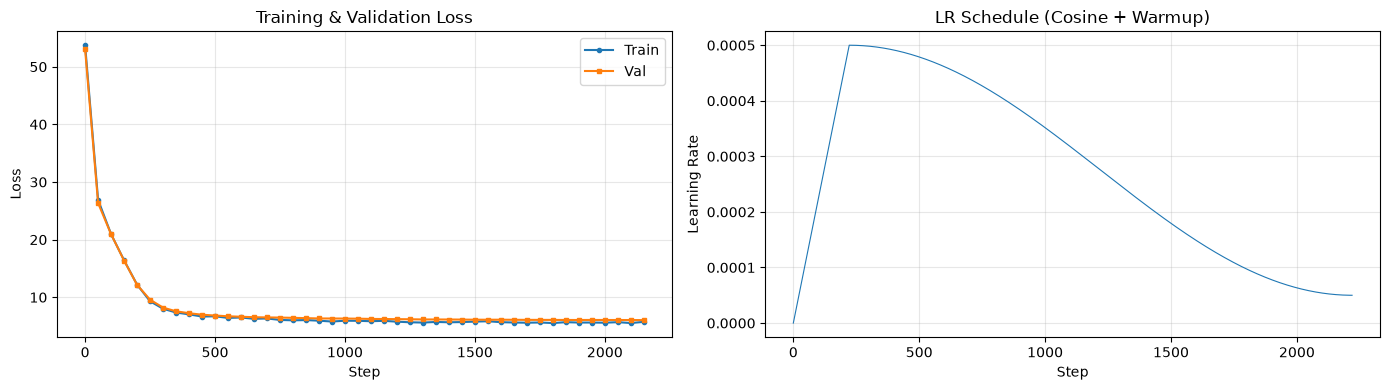

Final Train Loss: 5.7315
Final Val Loss:   6.0371
Final Perplexity: 418.7


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

steps = [i * 50 for i in range(len(result['train_losses']))]
axes[0].plot(steps, result['train_losses'], label='Train', marker='o', markersize=3)
axes[0].plot(steps, result['val_losses'], label='Val', marker='s', markersize=3)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result['lrs'], linewidth=0.8)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('LR Schedule (Cosine + Warmup)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Loss: {result["train_losses"][-1]:.4f}')
print(f'Final Val Loss:   {result["val_losses"][-1]:.4f}')
print(f'Final Perplexity: {math.exp(result["val_losses"][-1]):.1f}')

## 6. Generate

In [7]:
from minigpt.generate import generate

model.eval()

prompts = [
    'ROMEO:',
    'To be or not to be',
    'KING HENRY:',
    'The world is',
]

for prompt in prompts:
    input_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)
    with torch.no_grad():
        output_ids = generate(
            model, input_ids,
            max_new_tokens=100,
            context_length=SMALL_CONFIG['context_length'],
        )
    print(f'--- {prompt} ---')
    print(tokenizer.decode(output_ids[0].tolist()))
    print()

--- ROMEO: ---
ROMEO:







IUS:

IUS:

IUS:

IUS:



IUS:


IUS:



IUS:

IUS:


IUS:
IUS:



IUS:
IUS:

IUS:
IUS:
IUS:

IUS:



IUS:

I

--- To be or not to be ---
To be or not to be,
And,
And,
And,
And,
And,
The,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And I have I have,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And I have,

--- KING HENRY: ---
KING HENRY:





And:

And:
I, I have the king,



And I have you,
And,
And I have,
And,
And,
The,
And I have theI'll the I have the king,
And,
And I have I,
And,
And,
And I have you,
And,
And,
And,
And I have,
And I have you,

--- The world is ---
The world is,






And I have you,
And,
And I have,
And,
And,
And,
And I,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And,
And I have I,
And,
And,
And I have,
And,
And,
And,
And I have,
And,
And

